In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob
import pandas as pd

path = "/content/drive/MyDrive/공모전/T18/*.csv"
files = glob.glob(path)

print(f"총 파일 수: {len(files)}개")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print(f"전체 행 수: {len(df):,}")
print(f"컬럼 수: {len(df.columns)}")
print(df.columns.tolist())
print(df.head())

총 파일 수: 36개
전체 행 수: 160,898
컬럼 수: 24
['ETL_YM', 'DOW', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT', 'DURATION', 'ETL_YM ', ' DOW ', ' D_CTY_CD ', ' D_MEGA_NM ', ' D_CTY_NM ', ' D_CENTER_X ', ' D_CENTER_Y ', ' TRANS_GB ', ' SEX_CD ', ' AGE_GRP ', ' CNT ', ' DURATION']
   ETL_YM DOW  D_CTY_CD D_MEGA_NM D_CTY_NM  D_CENTER_X  D_CENTER_Y  TRANS_GB  \
0  202412   수   41133.0       경기도  성남시 중원구    970268.0   1937199.0       1.0   
1  202412   금   41135.0       경기도  성남시 분당구    965120.0   1931210.0       0.0   
2  202412   목   41131.0       경기도  성남시 수정구    964981.0   1937423.0       1.0   
3  202412   일   41131.0       경기도  성남시 수정구    964981.0   1937423.0       1.0   
4  202412   금   41133.0       경기도  성남시 중원구    970268.0   1937199.0       3.0   

  SEX_CD  AGE_GRP  ...   D_CTY_CD    D_MEGA_NM    D_CTY_NM   D_CENTER_X   \
0      M      5.0  ...         NaN          NaN         NaN          NaN   
1      F      9.0  ...         NaN     

In [ ]:
!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
# ── 2+3. 컬럼 정리 + 타입 정리 + 전처리 한번에 ──────────────

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 한글 폰트
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
fontprop = fm.FontProperties(fname=font_path)
mpl.rcParams['axes.unicode_minus'] = False

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

# 중복 컬럼 제거
df = df.loc[:, ~df.columns.duplicated()]

# 결측치 제거 (빈 행)
df = df.dropna(subset=["ETL_YM"]).copy()
print(f"결측치 제거 후 행 수: {len(df):,}")

# 타입 정리
df["ETL_YM"]   = df["ETL_YM"].astype(str).str.strip().str[:6]
df["TRANS_GB"] = df["TRANS_GB"].astype(float).astype(int)
df["AGE_GRP"]  = df["AGE_GRP"].astype(float).astype(int)
df["CNT"]      = pd.to_numeric(df["CNT"], errors="coerce")
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 성남시 필터
df_sn = df[df["D_CTY_NM"].str.contains("성남", na=False)].copy()

# 연도·월 컬럼 추가
df_sn["year"]  = df_sn["ETL_YM"].str[:4]
df_sn["month"] = df_sn["ETL_YM"].str[4:6]

# 이동수단 한글 매핑
trans_map = {0: "차량", 1: "노선버스", 2: "지하철", 3: "도보", 4: "기타차량", 5: "항공", 6: "기타", 7: "기타"}
df_sn["TRANS_NM"] = df_sn["TRANS_GB"].map(trans_map)

# 연령대 한글 매핑
age_map = {1:"10대미만", 2:"10대", 3:"20대", 4:"30대", 5:"40대", 6:"50대", 7:"60대", 8:"70대", 9:"80대이상"}
df_sn["AGE_NM"] = df_sn["AGE_GRP"].map(age_map)

# 성별 한글
df_sn["SEX_NM"] = df_sn["SEX_CD"].map({"M": "남성", "W": "여성", "F": "여성"})

print(f"성남시 데이터: {len(df_sn):,}행")
print(f"기간: {df_sn['ETL_YM'].min()} ~ {df_sn['ETL_YM'].max()}")
print(f"\n구별 분포:\n{df_sn['D_CTY_NM'].value_counts()}")
print(f"\n이동수단 분포:\n{df_sn['TRANS_NM'].value_counts()}")

결측치 제거 후 행 수: 151,531
성남시 데이터: 151,531행
기간: 202301 ~ 화

구별 분포:
D_CTY_NM
성남시 분당구    53878
성남시 수정구    49379
성남시 중원구    48274
Name: count, dtype: int64

이동수단 분포:
TRANS_NM
기타      34432
도보      23810
차량      23398
노선버스    22972
지하철     21799
항공      15830
기타차량     9290
Name: count, dtype: int64


In [ ]:
# ── 데이터 이상 확인 ────────────────────────────────────────

# ETL_YM 이상값 확인
print("ETL_YM 고유값 샘플:")
print(df["ETL_YM"].unique()[:20])

# D_MEGA_NM 확인 (경기도 외 다른 지역 있는지)
print(f"\n시도 종류:\n{df['D_MEGA_NM'].value_counts()}")

# DOW 고유값 확인
print(f"\n요일 고유값:\n{df['DOW'].value_counts()}")

ETL_YM 고유값 샘플:
['202412' '202407' '202408' '202409' '202410' '202411' '202406' '202404'
 '202405' '202403' '202402' '월' '화' '금' '토' '일' '수' '목' '202309' '202312']

시도 종류:
D_MEGA_NM
경기도    151531
Name: count, dtype: int64

요일 고유값:
DOW
일     14352
토     14330
금     14177
월     14158
화     14121
목     14081
수     14080
17     2582
16     2569
18     2551
20     2522
19     2516
15     2495
13     2489
12     2485
21     2472
22     2462
11     2427
14     2421
10     2336
9      2253
23     2229
8      2154
7      2025
6      1899
5      1737
1      1618
4      1614
2      1586
3      1552
0      1238
Name: count, dtype: int64


In [ ]:
# ── CSV 파일별 첫 행 확인 후 올바르게 병합 ──────────────────
import glob
import pandas as pd

path = "/content/drive/MyDrive/공모전/T18/*.csv"
files = glob.glob(path)

normal, broken = [], []

for f in files:
    temp = pd.read_csv(f, nrows=1)
    if "ETL_YM" in temp.columns:
        normal.append(f)
    else:
        broken.append(f)

print(f"정상 파일: {len(normal)}개")
print(f"헤더 없는 파일: {len(broken)}개")
print("\n헤더 없는 파일 목록:")
for f in broken:
    print(" ", f.split("/")[-1])

정상 파일: 33개
헤더 없는 파일: 3개

헤더 없는 파일 목록:
  T18_GG_TRANS_SEXAGE_DURATION_SGG_INFLOW_202501_성남시.csv
  T18_GG_TRANS_SEXAGE_DURATION_SGG_INFLOW_202503_성남시.csv
  T18_GG_TRANS_SEXAGE_DURATION_SGG_INFLOW_202502_성남시.csv


In [ ]:
# ── 올바르게 다시 병합 (공백 제거 포함) ─────────────────────

cols = pd.read_csv(normal[0], nrows=0).columns.tolist()
cols = [c.strip() for c in cols]  # 컬럼명 공백 제거

# 정상 파일 병합
df_normal = pd.concat([pd.read_csv(f) for f in normal], ignore_index=True)
df_normal.columns = df_normal.columns.str.strip()

# 헤더 없는 파일 병합
df_broken = pd.concat([pd.read_csv(f, header=None, names=cols) for f in broken], ignore_index=True)

# 합치기
df = pd.concat([df_normal, df_broken], ignore_index=True)
df = df.loc[:, ~df.columns.duplicated()]

print(f"최종 전체 행 수: {len(df):,}")

# 결측치 제거
df = df.dropna(subset=["ETL_YM"]).copy()

# ETL_YM 이상값 제거 (숫자 6자리만 유지)
df = df[df["ETL_YM"].astype(str).str.match(r"^\d{6}$")].copy()
print(f"이상값 제거 후 행 수: {len(df):,}")

# 타입 정리
df["ETL_YM"]   = df["ETL_YM"].astype(str).str.strip()
df["TRANS_GB"] = pd.to_numeric(df["TRANS_GB"], errors="coerce").astype("Int64")
df["AGE_GRP"]  = pd.to_numeric(df["AGE_GRP"],  errors="coerce").astype("Int64")
df["CNT"]      = pd.to_numeric(df["CNT"],      errors="coerce")
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 성남시 필터
df_sn = df[df["D_CTY_NM"].str.contains("성남", na=False)].copy()

# 연도·월 추가
df_sn["year"]  = df_sn["ETL_YM"].str[:4]
df_sn["month"] = df_sn["ETL_YM"].str[4:6]

# 이동수단 한글 매핑
trans_map = {0:"차량", 1:"노선버스", 2:"지하철", 3:"도보", 4:"기타차량", 5:"항공", 6:"기타", 7:"기타"}
df_sn["TRANS_NM"] = df_sn["TRANS_GB"].map(trans_map)

# 연령대 한글 매핑
age_map = {1:"10대미만", 2:"10대", 3:"20대", 4:"30대", 5:"40대", 6:"50대", 7:"60대", 8:"70대", 9:"80대이상"}
df_sn["AGE_NM"] = df_sn["AGE_GRP"].map(age_map)

# 성별 한글
df_sn["SEX_NM"] = df_sn["SEX_CD"].map({"M":"남성", "W":"여성", "F":"여성"})

# 확인
print(f"\n성남시 데이터: {len(df_sn):,}행")
print(f"기간: {df_sn['ETL_YM'].min()} ~ {df_sn['ETL_YM'].max()}")
print(f"\n구별 분포:\n{df_sn['D_CTY_NM'].value_counts()}")
print(f"\n이동수단 분포:\n{df_sn['TRANS_NM'].value_counts()}")

최종 전체 행 수: 160,901
이상값 제거 후 행 수: 108,666

성남시 데이터: 108,666행
기간: 202301 ~ 202512

구별 분포:
D_CTY_NM
성남시 분당구    38316
성남시 수정구    35428
성남시 중원구    34922
Name: count, dtype: int64

이동수단 분포:
TRANS_NM
기타      25990
차량      15323
도보      15237
노선버스    15084
지하철     14934
항공      12674
기타차량     9424
Name: count, dtype: int64


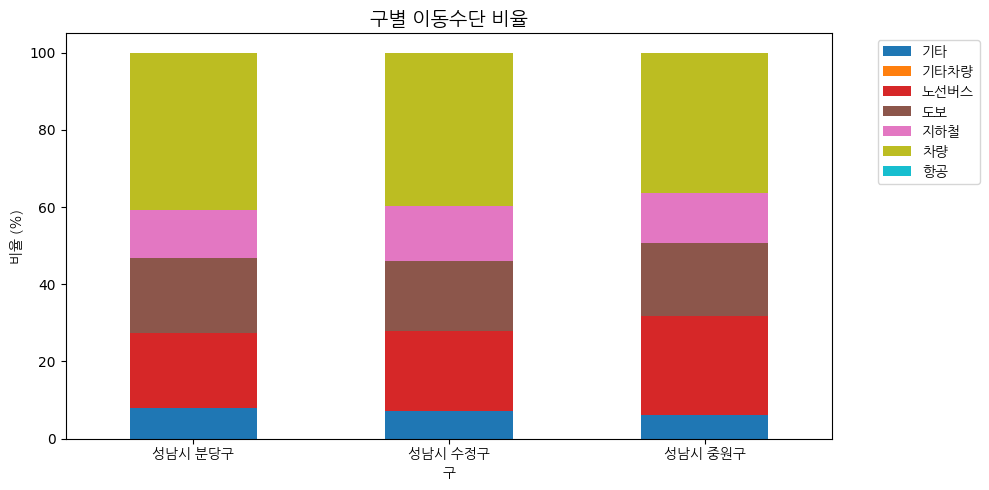

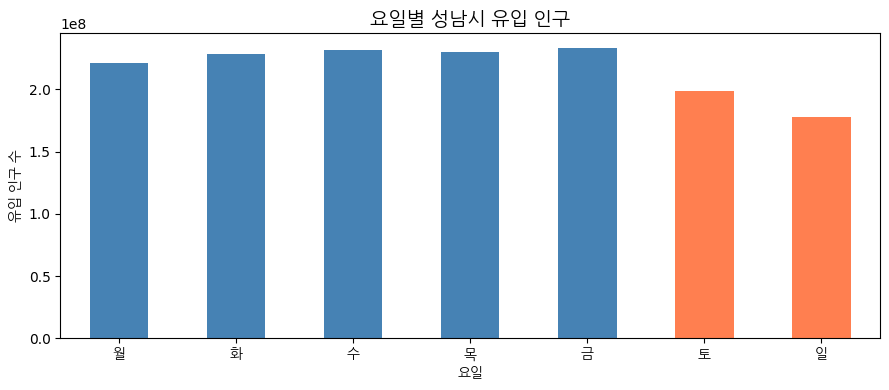

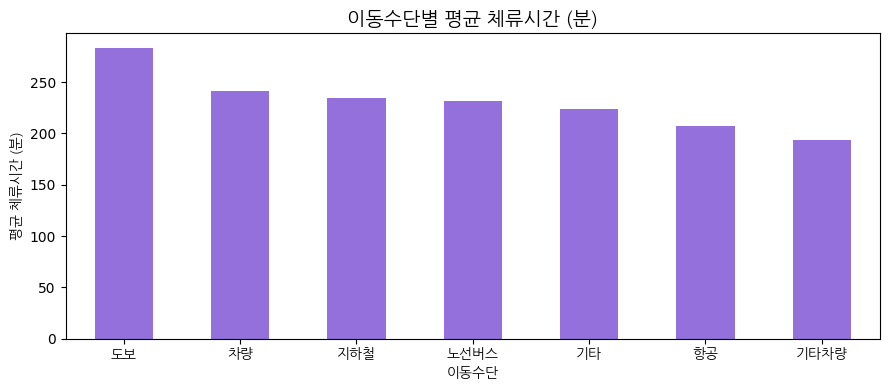

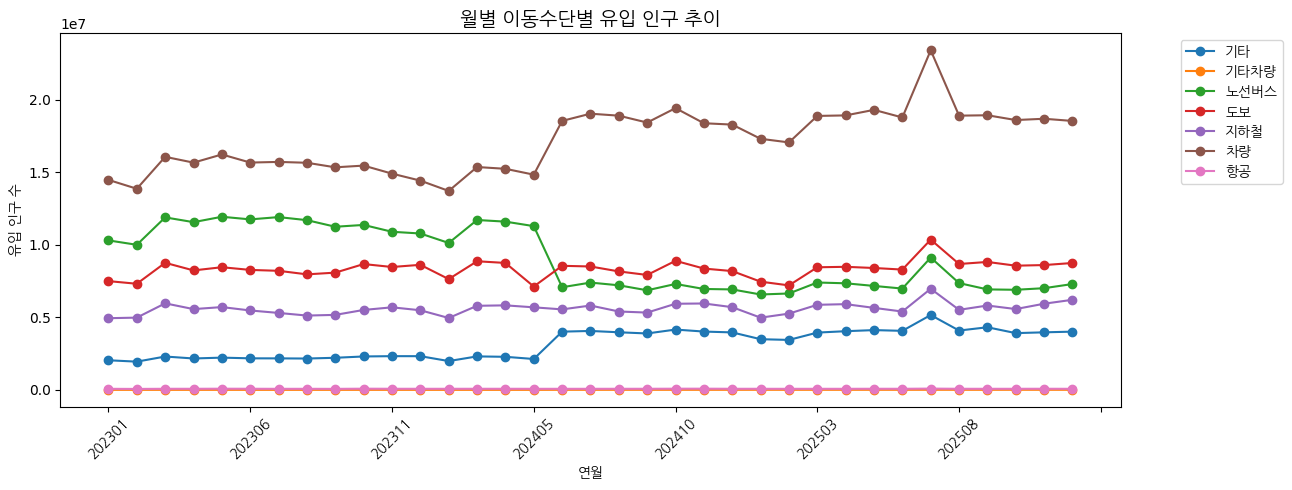

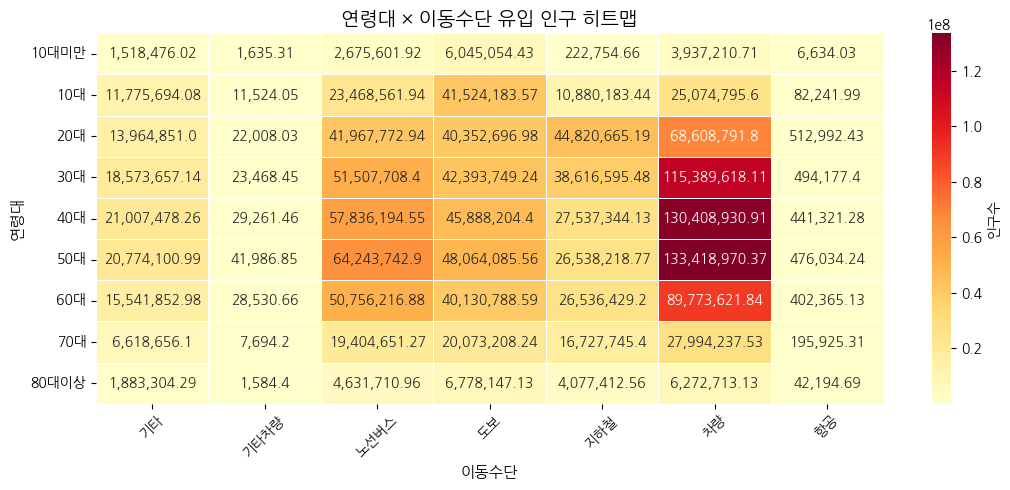

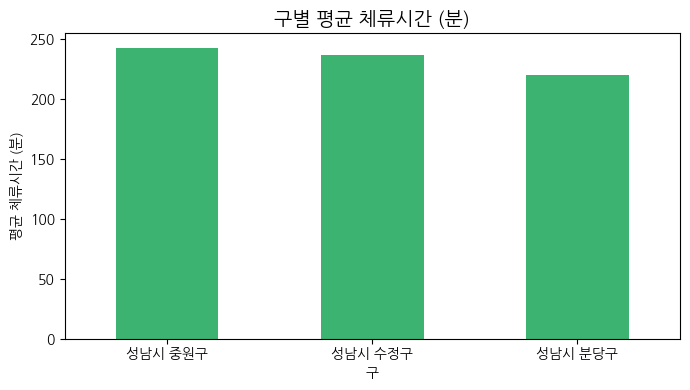

In [ ]:
# ── 시각화 전체 ───────────────────────────────────────────────

# ── 그래프 1 : 구별 이동수단 비율 ────────────────────────────
trans_gu = df_sn.groupby(["D_CTY_NM", "TRANS_NM"])["CNT"].sum().unstack()
trans_gu_pct = trans_gu.div(trans_gu.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
trans_gu_pct.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("구별 이동수단 비율", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("구", fontproperties=fontprop)
ax.set_ylabel("비율 (%)", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
ax.legend(prop=fontprop, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── 그래프 2 : 요일별 유입 인구 ──────────────────────────────
dow_order = ["월", "화", "수", "목", "금", "토", "일"]
dow_cnt = df_sn.groupby("DOW")["CNT"].sum().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["steelblue"]*5 + ["coral"]*2
dow_cnt.plot(kind="bar", ax=ax, color=colors)
ax.set_title("요일별 성남시 유입 인구", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("요일", fontproperties=fontprop)
ax.set_ylabel("유입 인구 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 3 : 이동수단별 평균 체류시간 ──────────────────────
trans_dur = df_sn.groupby("TRANS_NM")["DURATION"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
trans_dur.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("이동수단별 평균 체류시간 (분)", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("이동수단", fontproperties=fontprop)
ax.set_ylabel("평균 체류시간 (분)", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 4 : 월별 이동수단 트렌드 ─────────────────────────
trans_month = df_sn.groupby(["ETL_YM", "TRANS_NM"])["CNT"].sum().unstack().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
trans_month.plot(marker="o", ax=ax)
ax.set_title("월별 이동수단별 유입 인구 추이", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("연월", fontproperties=fontprop)
ax.set_ylabel("유입 인구 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=45)
ax.legend(prop=fontprop, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── 그래프 5 : 연령대별 이동수단 히트맵 ──────────────────────
import seaborn as sns

# seaborn용 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

age_order = ["10대미만","10대","20대","30대","40대","50대","60대","70대","80대이상"]
age_trans = df_sn.groupby(["AGE_NM", "TRANS_NM"])["CNT"].sum().unstack()
age_trans = age_trans.reindex([a for a in age_order if a in age_trans.index])

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(age_trans, ax=ax, cmap="YlOrRd", fmt=",", annot=True,
            linewidths=0.5, cbar_kws={"label": "인구수"})
ax.set_title("연령대 × 이동수단 유입 인구 히트맵", fontsize=14)
ax.set_xlabel("이동수단", fontsize=11)
ax.set_ylabel("연령대", fontsize=11)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 6 : 구별 평균 체류시간 비교 ───────────────────────
gu_dur = df_sn.groupby("D_CTY_NM")["DURATION"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
gu_dur.plot(kind="bar", ax=ax, color="mediumseagreen")
ax.set_title("구별 평균 체류시간 (분)", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("구", fontproperties=fontprop)
ax.set_ylabel("평균 체류시간 (분)", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# 연도별 데이터 분포 확인
print("연도별 행 수:")
print(df_sn.groupby("year")["CNT"].count())

print("\n연월별 행 수:")
print(df_sn.groupby("ETL_YM")["CNT"].count().sort_index())

연도별 행 수:
year
2023    36709
2024    34190
2025    37767
Name: CNT, dtype: int64

연월별 행 수:
ETL_YM
202301    3035
202302    3035
202303    3021
202304    3054
202305    3079
202306    3065
202307    3066
202308    3083
202309    3062
202310    3091
202311    3062
202312    3056
202402    3084
202403    3051
202404    3082
202405    3093
202406    3129
202407    3120
202408    3155
202409    3124
202410    3141
202411    3100
202412    3111
202501    3140
202502    3113
202503    3114
202504    3140
202505    3176
202506    3147
202507    3135
202508    3177
202509    3146
202510    3193
202511    3141
202512    3145
Name: CNT, dtype: int64


In [14]:
# 2024년 1월 파일 직접 확인
jan_file = [f for f in files if "202401" in f]
print("파일 경로:", jan_file)

# 파일 직접 읽어보기
temp = pd.read_csv(jan_file[0])
print(f"\n행 수: {len(temp)}")
print(f"컬럼: {temp.columns.tolist()}")
print(temp.head(3))
print(f"\nETL_YM 고유값: {temp['ETL_YM'].unique()[:5]}")

파일 경로: ['/content/drive/MyDrive/공모전/T18/T18_GG_TRANS_SEXAGE_DURATION_SGG_INFLOW_202401_성남시.csv']

행 수: 52232
컬럼: ['ETL_YM', 'DOW', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT', 'DURATION']
       ETL_YM  DOW  D_CTY_CD D_MEGA_NM D_CTY_NM  D_CENTER_X  D_CENTER_Y  \
202401      월   13     41135       경기도  성남시 분당구      965120     1931210   
202401      화   19     41135       경기도  성남시 분당구      965120     1931210   
202401      금   10     41135       경기도  성남시 분당구      965120     1931210   

        TRANS_GB SEX_CD  AGE_GRP      CNT  DURATION  
202401         1      W        5  6764.48    190.61  
202401         3      W        6  5479.82    211.64  
202401         3      M        7  1251.39    244.45  

ETL_YM 고유값: ['월' '화' '금' '토' '일']


2024.1 누락되어 다시 진행함

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
불러올 총 파일 수: 36개
병합 직후 전체 행 수: 160,898행
전처리 완료 후 성남시 데이터: 108,666행
데이터 기간: 202301 ~ 202512


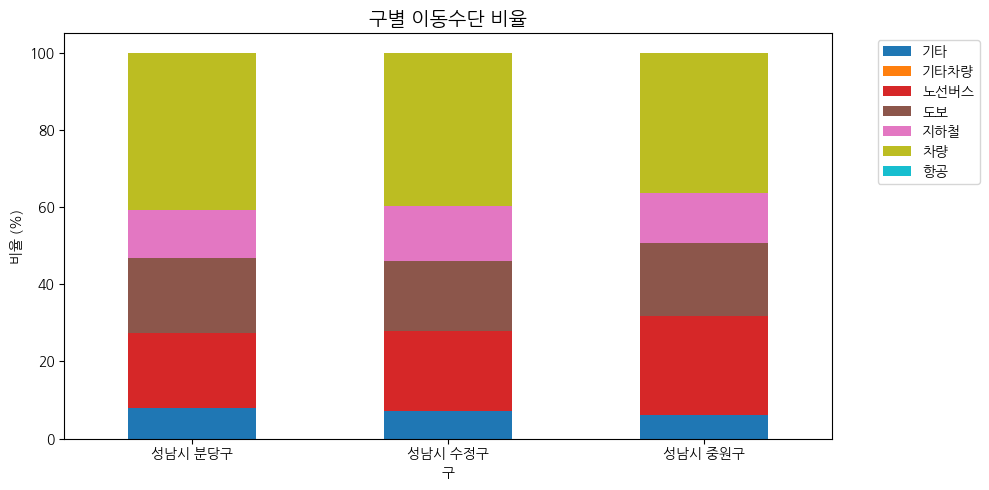

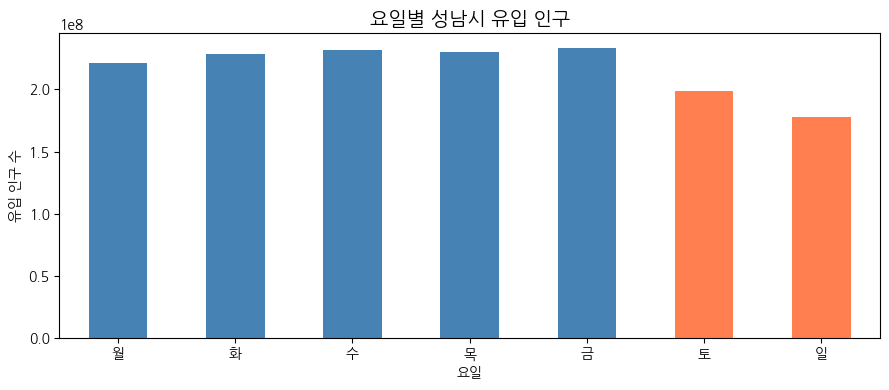

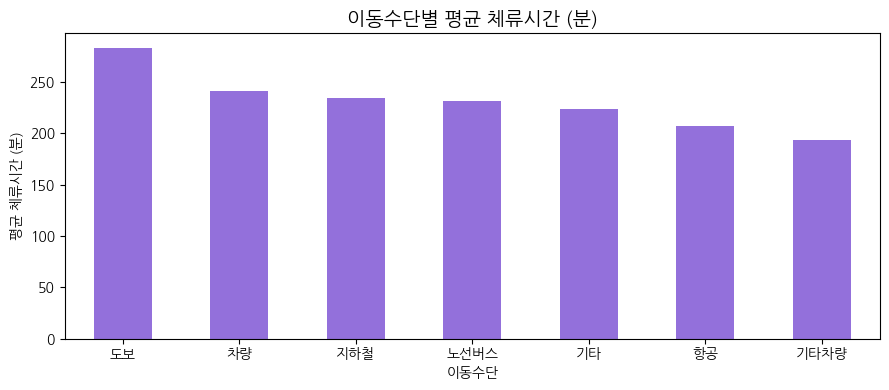

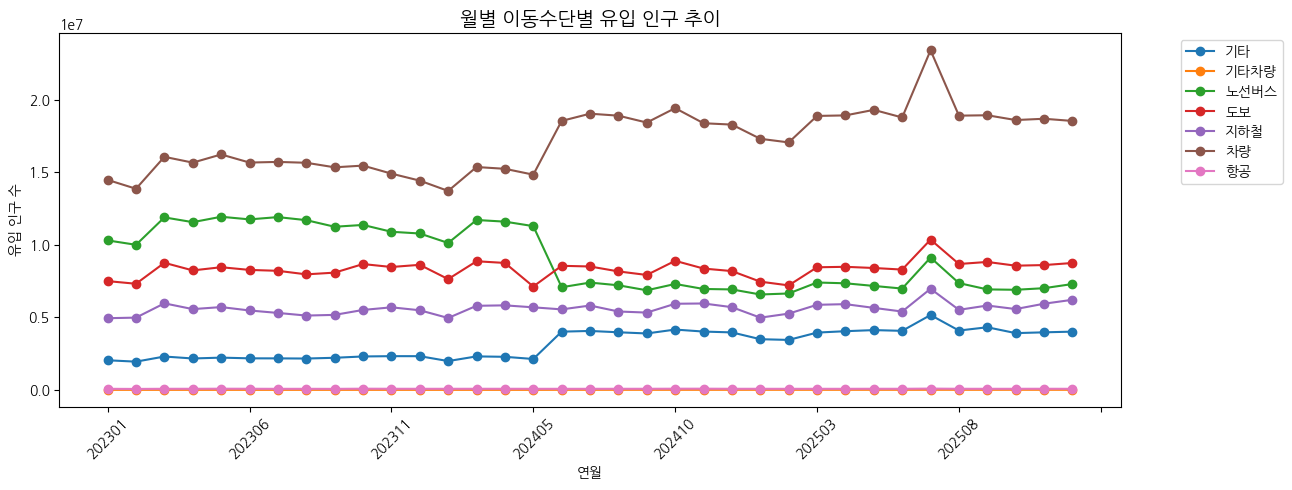

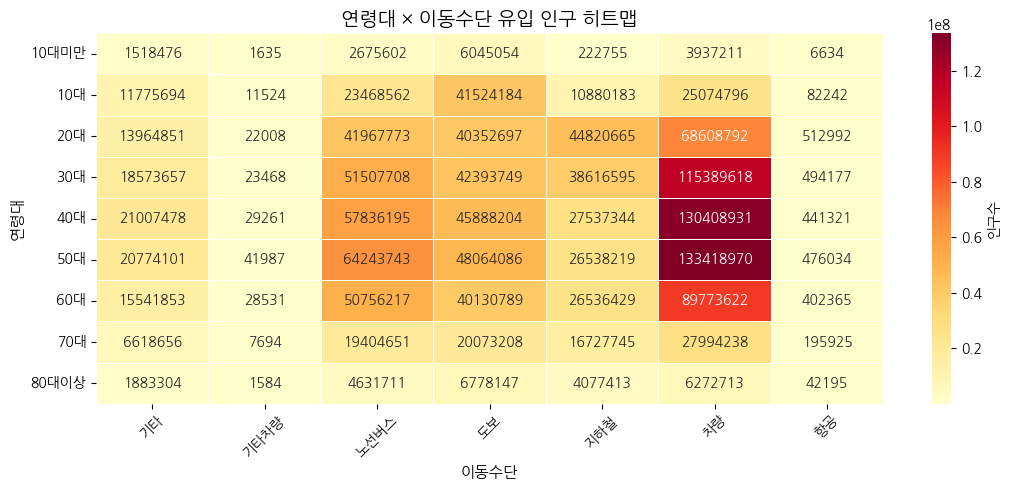

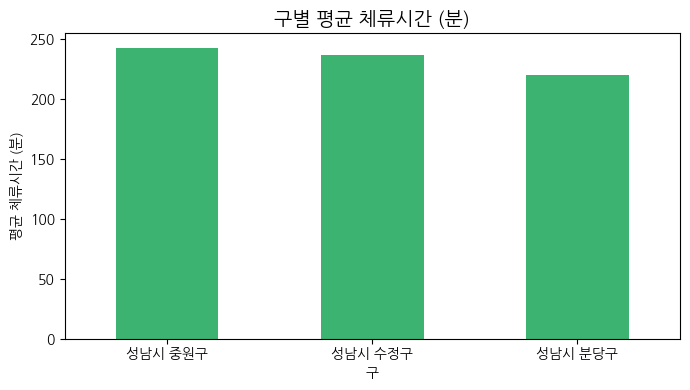

In [15]:
# 0. 구글 드라이브 마운트 (이미 되어있다면 생략 가능)
from google.colab import drive
drive.mount('/content/drive')

# 1. 라이브러리 임포트 및 폰트 설정
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정 (Colab 환경 나눔고딕 기준)
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
try:
    fm.fontManager.addfont(font_path)
    fontprop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
except:
    fontprop = fm.FontProperties()
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 데이터 불러오기 및 병합 (2024.1 데이터 누락 해결)
# ==========================================
path = "/content/drive/MyDrive/공모전/T18/*.csv"
files = glob.glob(path)

print(f"불러올 총 파일 수: {len(files)}개")

df_list = []

# 첫 번째 파일에서 기준 컬럼명 추출
if files:
    cols = pd.read_csv(files[0], nrows=0).columns.str.strip().tolist()

    for f in files:
        # 컬럼명 확인을 위해 1줄만 먼저 읽기
        temp = pd.read_csv(f, nrows=1)

        # 헤더가 있는 파일인지 확인 (ETL_YM 컬럼명 포함 여부)
        if any("ETL_YM" in col for col in temp.columns):
            temp_df = pd.read_csv(f)
            # ★ 핵심: 병합 전에 각 데이터프레임의 컬럼명 공백을 완벽히 제거
            temp_df.columns = temp_df.columns.str.strip()
            df_list.append(temp_df)
        else:
            # 헤더가 없는 파일인 경우
            temp_df = pd.read_csv(f, header=None, names=cols)
            df_list.append(temp_df)

# 데이터 병합 및 중복 컬럼 제거
df = pd.concat(df_list, ignore_index=True)
df = df.loc[:, ~df.columns.duplicated()]

print(f"병합 직후 전체 행 수: {len(df):,}행")

# ==========================================
# 3. 데이터 전처리
# ==========================================
# 결측치 및 ETL_YM 이상값 제거 (숫자 6자리 연월만 유지)
df = df.dropna(subset=["ETL_YM"]).copy()
df = df[df["ETL_YM"].astype(str).str.strip().str.match(r"^\d{6}$")].copy()

# 데이터 타입 정리
df["ETL_YM"]   = df["ETL_YM"].astype(str).str.strip()
df["TRANS_GB"] = pd.to_numeric(df["TRANS_GB"], errors="coerce").astype("Int64")
df["AGE_GRP"]  = pd.to_numeric(df["AGE_GRP"], errors="coerce").astype("Int64")
df["CNT"]      = pd.to_numeric(df["CNT"], errors="coerce")
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 성남시 데이터 필터링
df_sn = df[df["D_CTY_NM"].str.contains("성남", na=False)].copy()

# 파생변수 생성 (연, 월, 한글 라벨 매핑)
df_sn["year"]  = df_sn["ETL_YM"].str[:4]
df_sn["month"] = df_sn["ETL_YM"].str[4:6]

trans_map = {0:"차량", 1:"노선버스", 2:"지하철", 3:"도보", 4:"기타차량", 5:"항공", 6:"기타", 7:"기타"}
df_sn["TRANS_NM"] = df_sn["TRANS_GB"].map(trans_map)

age_map = {1:"10대미만", 2:"10대", 3:"20대", 4:"30대", 5:"40대", 6:"50대", 7:"60대", 8:"70대", 9:"80대이상"}
df_sn["AGE_NM"] = df_sn["AGE_GRP"].map(age_map)

df_sn["SEX_NM"] = df_sn["SEX_CD"].map({"M":"남성", "W":"여성", "F":"여성"})

print(f"전처리 완료 후 성남시 데이터: {len(df_sn):,}행")
print(f"데이터 기간: {df_sn['ETL_YM'].min()} ~ {df_sn['ETL_YM'].max()}")

# ==========================================
# 4. 데이터 시각화
# ==========================================

# ── 그래프 1 : 구별 이동수단 비율
trans_gu = df_sn.groupby(["D_CTY_NM", "TRANS_NM"])["CNT"].sum().unstack()
trans_gu_pct = trans_gu.div(trans_gu.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
trans_gu_pct.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("구별 이동수단 비율", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("구", fontproperties=fontprop)
ax.set_ylabel("비율 (%)", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
ax.legend(prop=fontprop, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── 그래프 2 : 요일별 유입 인구
dow_order = ["월", "화", "수", "목", "금", "토", "일"]
dow_cnt = df_sn.groupby("DOW")["CNT"].sum().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["steelblue"]*5 + ["coral"]*2
dow_cnt.plot(kind="bar", ax=ax, color=colors)
ax.set_title("요일별 성남시 유입 인구", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("요일", fontproperties=fontprop)
ax.set_ylabel("유입 인구 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 3 : 이동수단별 평균 체류시간
trans_dur = df_sn.groupby("TRANS_NM")["DURATION"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
trans_dur.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("이동수단별 평균 체류시간 (분)", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("이동수단", fontproperties=fontprop)
ax.set_ylabel("평균 체류시간 (분)", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 4 : 월별 이동수단 트렌드
trans_month = df_sn.groupby(["ETL_YM", "TRANS_NM"])["CNT"].sum().unstack().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
trans_month.plot(marker="o", ax=ax)
ax.set_title("월별 이동수단별 유입 인구 추이", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("연월", fontproperties=fontprop)
ax.set_ylabel("유입 인구 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=45)
ax.legend(prop=fontprop, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── 그래프 5 : 연령대별 이동수단 히트맵
age_order = ["10대미만","10대","20대","30대","40대","50대","60대","70대","80대이상"]
age_trans = df_sn.groupby(["AGE_NM", "TRANS_NM"])["CNT"].sum().unstack()
age_trans = age_trans.reindex([a for a in age_order if a in age_trans.index])

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(age_trans, ax=ax, cmap="YlOrRd", fmt=".0f", annot=True,
            linewidths=0.5, cbar_kws={"label": "인구수"})
ax.set_title("연령대 × 이동수단 유입 인구 히트맵", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("이동수단", fontproperties=fontprop, fontsize=11)
ax.set_ylabel("연령대", fontproperties=fontprop, fontsize=11)

# 히트맵 축 라벨 폰트 적용
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=45)
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=fontprop, rotation=0)

plt.tight_layout()
plt.show()

# ── 그래프 6 : 구별 평균 체류시간 비교
gu_dur = df_sn.groupby("D_CTY_NM")["DURATION"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
gu_dur.plot(kind="bar", ax=ax, color="mediumseagreen")
ax.set_title("구별 평균 체류시간 (분)", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("구", fontproperties=fontprop)
ax.set_ylabel("평균 체류시간 (분)", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()